# EDA features_alunos (Fase 3)

Essa é a análise exploratória da camada gold `features_alunos`, no grão aluno (1 linha por estudante avaliado em 2024)

Objetivo principal: entender distribuições, padrões e correlações que apoiem as decisões da etapa de modelagem, e formular hipóteses sobre os fatores associados à alfabetização.

| Principais pontos de foco do EDA |
|---|
| 1 - Compreender o comportamento dos dados |
| 2 - Identificar padrões |
| 3 - Avaliar distribuições |
| 4 - Detectar correlações |
| 5 - Analisar variáveis relevantes | 
| 6 - Formular hipóteses analíticas |

Foco principal da análise exploratória apoiar diretamente as decisões de modelagem.


## 1. Setup (Blibliotecas e configuracões)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

#Definir um tamanho padrão para os gráficos  
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='darkgrid', palette='muted')

#Avisos
import warnings
warnings.filterwarnings("ignore")

### 1.1 Valida se os arquivos .parquet estão na pasta gerando um erro caso não estejam e especificando para baixar os arquivos.
 

In [23]:
caminho_gold_local = Path("../data/sample/features_aluno")
BUCKET = "fiap-postech-challenge-fase2" #Ajustar para o nome do seu bucket

arquivos_parquet = sorted(caminho_gold_local.glob("*.parquet"))

if not arquivos_parquet:
    raise FileNotFoundError(
        f"Nenhum arquivo .parquet encontrados em '{caminho_gold_local}'.\n\n"
        "Baixe a gold do s3 antes de continuar, rodando no terminal "
        "(a partor da raiz do projeto): .\n\n"
        f" aws s3 cp s3://{BUCKET}/fase3/gold/features_aluno/'{caminho_gold_local}' --recursive\n"
    )
print(f"{len(arquivos_parquet)} arquivo(s) parquet encontrado(s) em '{caminho_gold_local}'.")

4 arquivo(s) parquet encontrado(s) em '..\data\sample\features_aluno'.


Lendo a Gold já baixada localmente em `data/sample/features_aluno/` (4 arquivos parquet), sem depender do Athena/S3 para reexecutar o notebook.

In [24]:
df = pd.read_parquet(caminho_gold_local)
df.shape

(1610754, 35)

## 2. Visão geral

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610754 entries, 0 to 1610753
Data columns (total 35 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   ano                               1610754 non-null  int32  
 1   id_aluno                          1610754 non-null  str    
 2   id_escola                         1610754 non-null  str    
 3   id_municipio                      1610754 non-null  str    
 4   sigla_uf                          1610754 non-null  str    
 5   regiao                            1610754 non-null  str    
 6   alfabetizado                      1610754 non-null  bool   
 7   peso_aluno                        1610754 non-null  float64
 8   uf_anomala                        1610754 non-null  bool   
 9   rede_codigo                       1610754 non-null  str    
 10  caderno                           1610754 non-null  str    
 11  mun_taxa_ano_anterior             1602506 non-nu

In [25]:
print(f"Linhas: {len(df):,}")
print(f"Municípios únicos: {df['id_municipio'].nunique():,}")
print(f"Escolas únicas: {df['id_escola'].nunique():,}")
print(f"UFs: {df['sigla_uf'].nunique()}")

Linhas: 1,610,754
Municípios únicos: 5,450
Escolas únicas: 36,920
UFs: 25


A validação realizada na Gold já bloqueia colunas 100% nulas e alvo nulo antes de gravar. Aqui só fazemos uma conferência — não esperamos nulos relevantes.

In [26]:
nulos = df.isna().mean().sort_values(ascending=False)
nulos[nulos > 0]

mun_distancia_meta_anterior         0.026172
mun_meta_ano_alvo                   0.026172
mun_taxa_ano_anterior               0.005121
mun_pct_va_administracao_publica    0.000060
mun_pct_va_agropecuaria             0.000060
mun_pct_va_industria                0.000060
mun_pct_va_servicos                 0.000060
mun_elegivel_meta                   0.000011
dtype: float64

Aqui fazemos ac onferência das colunas de vazamento direto (`proficiencia`, `distancia_corte`, `faixa_proximidade`) e da chave duplicada — se algo aparecer aqui, é bug na Gold, não na análise.

In [27]:
colunas_vazamento = {"proficiencia", "distancia_corte", "faixa_proximidade", "alvo_taxa_2024"}
print("Colunas de vazamento presentes:", colunas_vazamento & set(df.columns))
print("Chaves (ano, id_aluno) duplicadas:", df.duplicated(subset=["ano", "id_aluno"]).sum())

Colunas de vazamento presentes: set()
Chaves (ano, id_aluno) duplicadas: 0


## 3. Alvo (`alfabetizado`)

In [28]:
df["alfabetizado"].value_counts(normalize=True).mul(100).round(1)

alfabetizado
True     59.4
False    40.6
Name: proportion, dtype: float64

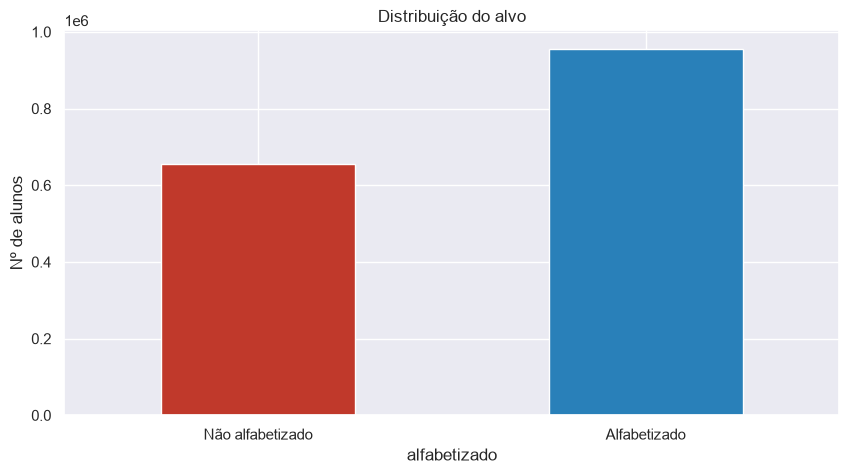

In [29]:
ax = df["alfabetizado"].value_counts().sort_index().plot(kind="bar", color=["#c0392b", "#2980b9"])
ax.set_xticklabels(["Não alfabetizado", "Alfabetizado"], rotation=0)
ax.set_ylabel("Nº de alunos")
ax.set_title("Distribuição do alvo")
plt.show()

Base relativamente balanceada (~59% positivos). Acurácia continua informativa, mas vale acompanhar precisão/recall — o custo de um falso negativo (deixar de sinalizar uma criança em risco) não é o mesmo de um falso positivo.

## 4. Pseudo-replicação

As features municipais se repetem em todos os alunos do mesmo município. O tamanho efetivo de amostra para essas variáveis é o número de municípios, não o de alunos — por isso a validação do modelo precisa agrupar por `id_municipio` (`GroupKFold`), e não usar um split aleatório.

In [30]:
alunos_por_municipio = df.groupby("id_municipio").size()
alunos_por_municipio.describe()

count     5450.000000
mean       295.551193
std       1101.752505
min          6.000000
25%         50.000000
50%        103.000000
75%        231.000000
max      43340.000000
dtype: float64

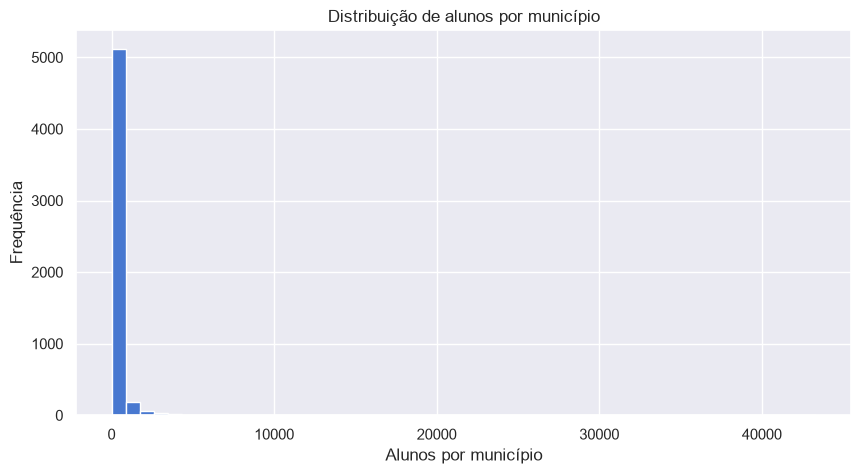

In [31]:
alunos_por_municipio.plot(kind="hist", bins=50)
plt.xlabel("Alunos por município")
plt.ylabel("Frequência")
plt.title("Distribuição de alunos por município")
plt.show()

## 5. Anomalia do Rio Grande do Sul

A Fase 2 já documenta um deslocamento uniforme nos municípios gaúchos, marcado em `uf_anomala`. Comparando a taxa de alfabetização e a taxa do ano anterior com o restante do país:

In [34]:
df.groupby("uf_anomala")["alfabetizado"].mean().mul(100).round(1)

uf_anomala
False    59.9
True     45.3
Name: alfabetizado, dtype: float64

### Para critérios de comparação

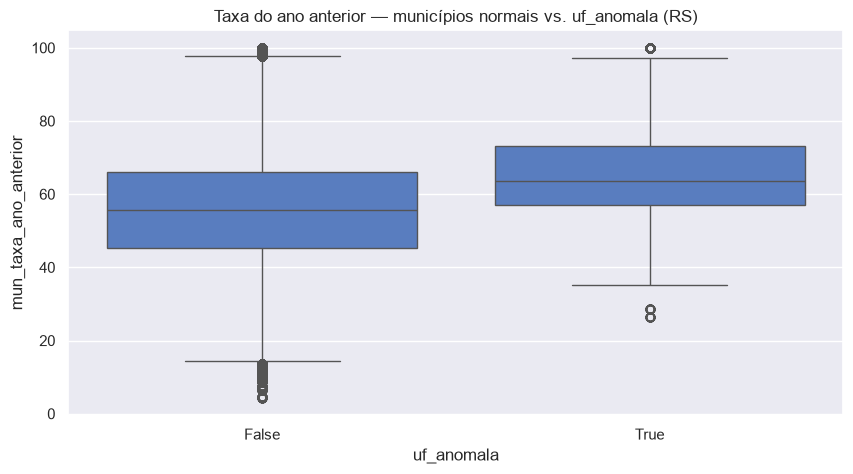

In [35]:
sns.boxplot(data=df, x="uf_anomala", y="mun_taxa_ano_anterior")
plt.title("Taxa do ano anterior — municípios normais vs. uf_anomala (RS)")
plt.show()

## 6. Features municipais x alvo

A Fase 2 encontrou um gradiente de infraestrutura escolar associado à taxa de alfabetização. Vale checar se o padrão se repete aqui, no grão do aluno.

In [41]:
df["quartil_infra"] = pd.qcut(df["mun_indice_infraestrutura"], 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
taxas_por_quartil = df.groupby("quartil_infra", observed=True)["alfabetizado"].mean().mul(100).round(1)
taxas_por_quartil

quartil_infra
Q1 (menor)    55.4
Q2            58.3
Q3            61.5
Q4 (maior)    62.3
Name: alfabetizado, dtype: float64

Antes de comemorar o gradiente, vale comparar com o que a Fase 2 já tinha encontrado — só que lá cada **município** valia 1 ponto, aqui cada **aluno** vale 1 ponto. Os números da Fase 2 abaixo vieram prontos de lá (não temos o código original, só a tabela final), então guardamos como referência fixa, não recalculada.

Se o gradiente se mantiver parecido nos dois grãos, é sinal de que a variável é robusta de verdade. Se encolher bastante — como parece que vai acontecer aqui —, isso já é um achado: o efeito da infraestrutura pode estar sendo "diluído" quando olhamos aluno a aluno, porque municípios grandes (com muitos alunos) pesam mais nessa conta do que pesavam na análise por município.

In [42]:
# Tabela da Fase 2 (grão do município) — valor de referência, não recalculado aqui
fase2_municipio = pd.DataFrame({
    "indice_medio": [58.5, 73.4, 83.4, 96.3],
    "taxa_media": [57.7, 60.6, 66.0, 67.0],
    "alunos_por_docente": [17.8, 17.5, 15.8, 14.9],
}, index=pd.Index(["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"], name="quartil_infra"))

print("Fase 2 — grão do município:")
print(fase2_municipio)

gap_municipio = fase2_municipio["taxa_media"].iloc[-1] - fase2_municipio["taxa_media"].iloc[0]
gap_aluno = taxas_por_quartil.iloc[-1] - taxas_por_quartil.iloc[0]

print(f"\nGap Q4 - Q1 no grão do município (Fase 2): {gap_municipio:.1f} p.p.")
print(f"Gap Q4 - Q1 no grão do aluno (Fase 3, aqui): {gap_aluno:.1f} p.p.")

Fase 2 — grão do município:
               indice_medio  taxa_media  alunos_por_docente
quartil_infra                                              
Q1 (menor)             58.5        57.7                17.8
Q2                     73.4        60.6                17.5
Q3                     83.4        66.0                15.8
Q4 (maior)             96.3        67.0                14.9

Gap Q4 - Q1 no grão do município (Fase 2): 9.3 p.p.
Gap Q4 - Q1 no grão do aluno (Fase 3, aqui): 6.9 p.p.


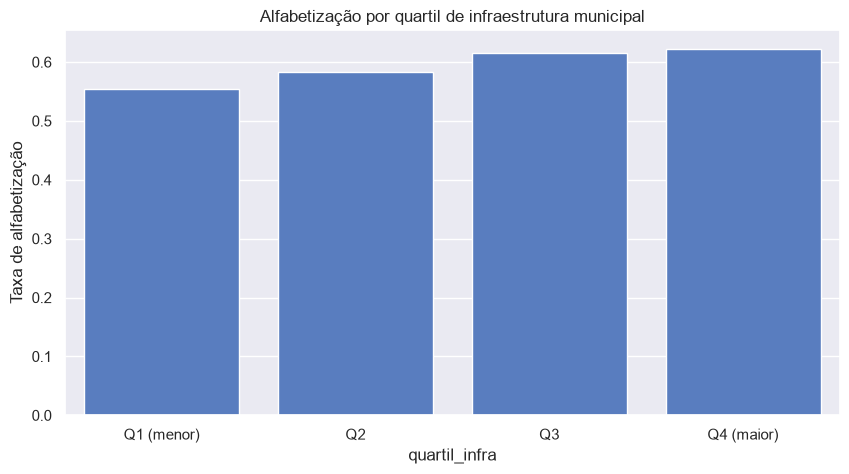

In [43]:
sns.barplot(data=df, x="quartil_infra", y="alfabetizado", errorbar=None)
plt.ylabel("Taxa de alfabetização")
plt.title("Alfabetização por quartil de infraestrutura municipal")
plt.show()

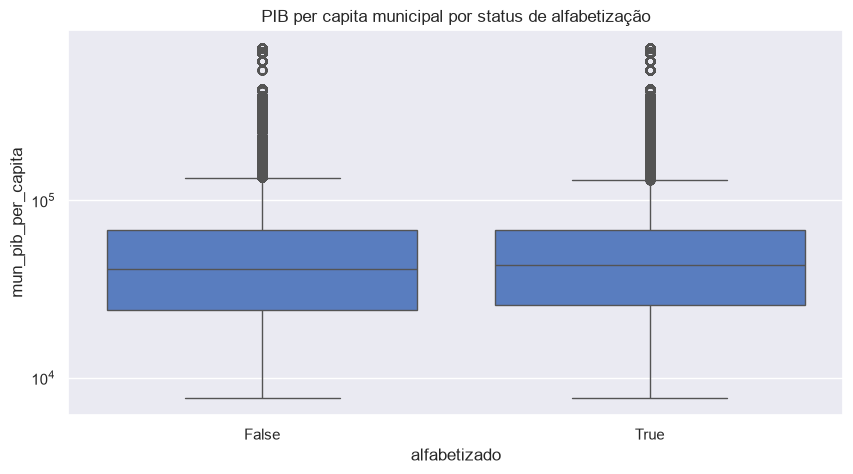

In [44]:
sns.boxplot(data=df, x="alfabetizado", y="mun_pib_per_capita")
plt.yscale("log")
plt.title("PIB per capita municipal por status de alfabetização")
plt.show()

## 7. Correlações

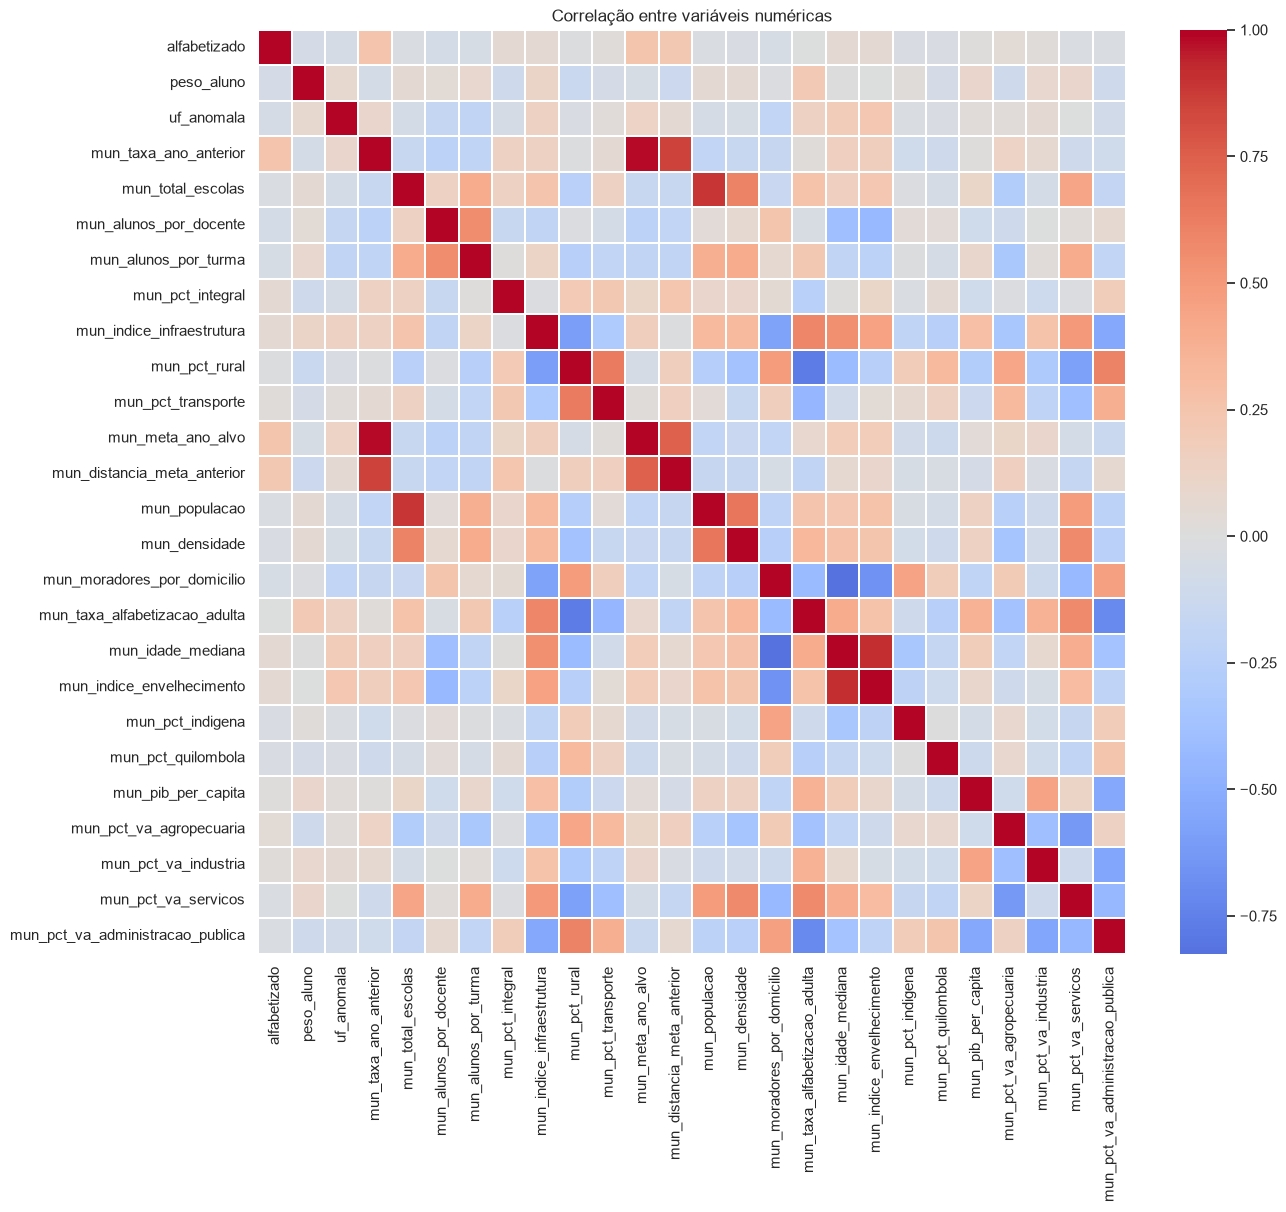

In [47]:
colunas_numericas = df.select_dtypes(include=["number", "bool"]).columns.drop(["ano", "id_municipio"], errors="ignore")
corr = df[colunas_numericas].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlação entre variáveis numéricas")
plt.show()

In [48]:
corr["alfabetizado"].drop("alfabetizado").sort_values(key=abs, ascending=False).head(15)

mun_taxa_ano_anterior          0.257427
mun_meta_ano_alvo              0.250960
mun_distancia_meta_anterior    0.221484
mun_alunos_por_docente        -0.071299
peso_aluno                    -0.063516
mun_pct_integral               0.057196
uf_anomala                    -0.056958
mun_indice_infraestrutura      0.054774
mun_idade_mediana              0.053594
mun_indice_envelhecimento      0.052973
mun_alunos_por_turma          -0.050390
mun_moradores_por_domicilio   -0.049570
mun_pct_va_agropecuaria        0.042447
mun_pct_indigena              -0.039996
mun_pct_quilombola            -0.035355
Name: alfabetizado, dtype: float64

## 8. Síntese e próximos passos

Depois de rodar todas as células acima, dá pra fechar com o que realmente encontramos — não mais "o que esperamos encontrar". A tabela abaixo já vem com o olhar de quem vai montar o pipeline de modelagem em seguida: cada achado tem uma implicação prática, não é só curiosidade.

| Achado | O que os dados mostraram | O que isso significa pra modelagem |
|---|---|---|
| Alvo relativamente balanceado | 59,4% alfabetizados vs. 40,6% não alfabetizados | Não parece necessário recorrer a técnicas pesadas de balanceamento (tipo SMOTE); acurácia continua informativa, mas vale acompanhar precisão/recall junto |
| Alunos muito mal distribuídos entre municípios | Mediana de 103 alunos por município, média de quase 296, e um caso extremo com 43 mil | Confirma a pseudo-replicação: um split aleatório por aluno deixaria o modelo "decorar" o contexto municipal. `GroupKFold` agrupando por `id_municipio` é obrigatório, não só recomendado |
| RS realmente destoa do resto do país | Taxa de 45,3% nos municípios marcados como `uf_anomala`, contra 59,9% nos demais | Alguém do time precisa decidir antes do treino: manter essas linhas como estão, usar `uf_anomala` como feature, ou excluir por suspeita de erro na origem do dado |
| Gradiente de infraestrutura existe, mas é mais fraco no grão do aluno | 6,9 p.p. entre pior e melhor quartil de infraestrutura aqui, contra 9,3 p.p. que a Fase 2 achou por município | A variável parece relevante, mas o efeito "encolhe" quando cada aluno pesa igual em vez de cada município. Vale conferir se ela aparece bem colocada no ranking de correlação |
| Nulos pequenos em 8 colunas | De 0,001% a 2,6% (as piores são as metas municipais, `mun_meta_ano_alvo` e `mun_distancia_meta_anterior`) | Nenhuma é grande o suficiente para descartar a coluna, mas o pipeline precisa de um `SimpleImputer` nelas — não dá pra deixar sem tratamento |
| Base íntegra | Nenhuma coluna de vazamento presente, zero chaves duplicadas | Não muda nada na modelagem em si, mas dá segurança de que a Gold está confiável antes de investir tempo treinando modelo em cima dela |
| Variáveis mais correlacionadas com o alvo | *(preencher depois de rodar a célula `corr-target`, já corrigida)* | Vai virar a primeira lista de candidatas a entrar no baseline de features da modelagem |

Esses achados alimentam diretamente as seções 2 (Objetivo analítico) e 9 (Insights) do README, ainda marcadas como pendentes — e servem de checklist pra quem for montar o `.py` de pré-processamento em `src/preprocessing/`.